In [1]:
import pandas as pd
import numpy as np
import os
import datetime

# Preprocress GHCN raw

In [7]:
folder = '/home/camarada/Documents/projects/temp-grss-nasa/ghcn_noaa/data/ghcnm.v4.0.1.20260330'
inv_file = "ghcnm.tavg.v4.0.1.20260330.qcf.inv"
dat_file = "ghcnm.tavg.v4.0.1.20260330.qcf.dat"

In [8]:
# Format: ID(11), LAT(9), LON(10), ELEV(7), NAME(30)
inv_specs = [(0, 11), (12, 20), (21, 30), (31, 37), (38, 68)]
inv_names = ['ID', 'LATITUDE', 'LONGITUDE', 'ELEVATION', 'NAME']

df_inv = pd.read_fwf(os.path.join(folder,inv_file), colspecs=inv_specs, names=inv_names)

In [9]:
df_inv.head()

,ID,LATITUDE,LONGITUDE,ELEVATION,NAME
0,ACW00011604,57.7667,11.8667,18.0,SAVE
1,AE000041196,25.3330,55.5170,34.0,SHARJAH_INTER_AIRP
2,AEM00041184,25.6170,55.9330,31.0,RAS_AL_KHAIMAH_INTE
3,AEM00041194,25.2550,55.3640,10.4,DUBAI_INTL
4,AEM00041216,24.4300,54.4700,3.0,ABU_DHABI_BATEEN_AIR


In [12]:
# --- 3. PARSE DATA (.dat) ---
# Structure: ID(11), Year(4), Element(4), then 12 months of [Value(5), DM(1), QC(1), DS(1)]
# We define the starting columns:
data_specs = [(0, 11), (11, 15), (15, 19)]
data_names = ['ID', 'YEAR', 'ELEMENT']

for i in range(1, 13):
    start = 19 + (i - 1) * 8
    data_specs.append((start, start + 5))      # Value
    data_specs.append((start + 5, start + 6))  # DM Flag
    data_specs.append((start + 6, start + 7))  # QC Flag
    data_specs.append((start + 7, start + 8))  # DS Flag
    
    data_names.extend([f'VALUE_{i}', f'DM_{i}', f'QC_{i}', f'DS_{i}'])

df_data = pd.read_fwf(os.path.join(folder,dat_file), colspecs=data_specs, names=data_names)

In [20]:
# --- 4. CLEANING & POST-PROCESSING ---
# Convert -9999 to NaN and scale temperatures (stored as 100 * Celsius)
value_cols = [f'VALUE_{i}' for i in range(1, 13)]
for col in value_cols:
    df_data[col] = df_data[col].replace(-9999, np.nan) / 100.0

# --- 5. MERGE & SAVE TO PARQUET ---
# Merge inventory info (Lat/Lon/Name) into the data dataframe
df_final = pd.merge(df_data, df_inv, on='ID', how='left')

# Save to Parquet (requires 'pyarrow' or 'fastparquet' installed)
df_final.to_parquet(f"data/ghcn_monthly_v4-{datetime.datetime.now().strftime("%Y-%m-%d-%H-%m")}.parquet", compression='snappy', index=False)

print(f"converted {len(df_final)} rows to Parquet.")
print(df_final.head())

Successfully converted 1489877 rows to Parquet.
            ID  YEAR ELEMENT  VALUE_1  DM_1 QC_1 DS_1  VALUE_2  DM_2 QC_2  \
0  ACW00011604  1961    TAVG  -0.0085   NaN  NaN    k   0.0240   NaN  NaN   
1  ACW00011604  1962    TAVG   0.0117   NaN  NaN    k   0.0089   NaN  NaN   
2  ACW00011604  1963    TAVG  -0.0709   NaN  NaN    k  -0.0549   NaN  NaN   
3  ACW00011604  1964    TAVG   0.0066   NaN  NaN    k  -0.0081   NaN  NaN   
4  ACW00011604  1965    TAVG   0.0048   NaN  NaN    k  -0.0101   NaN  NaN   

   ... QC_11  DS_11  VALUE_12 DM_12 QC_12  DS_12  LATITUDE LONGITUDE  \
0  ...   NaN      k   -0.0035   NaN   NaN      k   57.7667   11.8667   
1  ...   NaN      k   -0.0122   NaN   NaN      k   57.7667   11.8667   
2  ...   NaN      k   -0.0104   NaN   NaN      k   57.7667   11.8667   
3  ...   NaN      k    0.0116   NaN   NaN      k   57.7667   11.8667   
4  ...   NaN      k   -0.0174   NaN   NaN      k   57.7667   11.8667   

  ELEVATION  NAME  
0      18.0  SAVE  
1      18.0  SAV

## Load parquet back

In [2]:
df = pd.read_parquet('/home/camarada/Documents/projects/temp-grss-nasa/ghcn_noaa/data/ghcn_monthly_v4-2026-03-31-19-03.parquet')

In [6]:
#3 remove df object to release memory
del df

In [3]:
# we filter the data for a period higher than 1980
df_final = df.loc[df['YEAR'] >= 1990]
print(df_final.shape)

(560021, 55)


In [4]:
df_final.columns

Index(['ID', 'YEAR', 'ELEMENT', 'VALUE_1', 'DM_1', 'QC_1', 'DS_1', 'VALUE_2',
       'DM_2', 'QC_2', 'DS_2', 'VALUE_3', 'DM_3', 'QC_3', 'DS_3', 'VALUE_4',
       'DM_4', 'QC_4', 'DS_4', 'VALUE_5', 'DM_5', 'QC_5', 'DS_5', 'VALUE_6',
       'DM_6', 'QC_6', 'DS_6', 'VALUE_7', 'DM_7', 'QC_7', 'DS_7', 'VALUE_8',
       'DM_8', 'QC_8', 'DS_8', 'VALUE_9', 'DM_9', 'QC_9', 'DS_9', 'VALUE_10',
       'DM_10', 'QC_10', 'DS_10', 'VALUE_11', 'DM_11', 'QC_11', 'DS_11',
       'VALUE_12', 'DM_12', 'QC_12', 'DS_12', 'LATITUDE', 'LONGITUDE',
       'ELEVATION', 'NAME'],
      dtype='object')

In [7]:
## convert the data to a long format


# 2. Use wide_to_long to transform the dataframe
# stubnames: the prefixes of the columns we want to stack (VALUE and QC)
# i: the columns to keep as unique identifiers
# j: the name of the new column that will hold the month number (1-12)
df_long = pd.wide_to_long(
    df_final, 
    stubnames=['VALUE', 'QC', 'DM', 'DS'], 
    i=['ID', 'YEAR', 'LATITUDE', 'LONGITUDE', 'NAME'], 
    j='MONTH', 
    sep='_'
).reset_index()

# 3. Final Polish
# Rename 'VALUE' to 'TEMPERATURE' for clarity
df_long = df_long.rename(columns={'VALUE': 'TEMPERATURE', 'QC': 'QC_FLAG'})

# Sort by station and date
df_long = df_long.sort_values(['ID', 'YEAR', 'MONTH'])


In [11]:
df_long.to_parquet('data/long_format_ghcn1990-2026.parquet', compression='snappy', index=False)

In [16]:
df_long['DS'].unique()

array(['{', '}', None, '|', 'k', 'S', 'I', ']', "'", 'P', '3', '&', '"',
       'E', 'G', 'Z', 'w', '_', ',', 'r', '0', 'X', 'W', '7', 'H', '2',
       'f', 'l', 'y', '>', '^', 'a', 'h', '\\', '*', '#', ';', '$', 'Q',
       'b', 'i', '1', 'C', '8', '[', 'R', 's', 'J', 'K', 'L', 'q', 'e',
       'x', '?', '4', 'o', 'c', '9', '@', 'v', 'm', '=', 'p', ':', 'M',
       'A', 't', '+', '5', '!', '<', 'u', '`', '6', 'D', 'U', 'T', 'B',
       '-', '.', 'z'], dtype=object)

In [17]:
# Create a quick 'Summary' of flags by month to see the distribution
summary = df_long.groupby(['MONTH', 'QC_FLAG']).size().unstack(fill_value=0)
print(summary)

QC_FLAG     Q      X
MONTH               
1        5412  18757
2        5503  19186
3        5422  18767
4        5592  18599
5        5736  18533
6        5825  18572
7        6040  18524
8        6108  18544
9        5843  18471
10       5596  18415
11       5456  18262
12       5337  17876


In [18]:
df_long.columns

Index(['ID', 'YEAR', 'LATITUDE', 'LONGITUDE', 'NAME', 'MONTH', 'ELEMENT',
       'ELEVATION', 'TEMPERATURE', 'QC_FLAG', 'DM', 'DS'],
      dtype='object')

In [19]:
df_long['DM'].unique()

array([nan])

In [20]:
df_long.drop(columns='DM', inplace=True)

In [21]:
df_long.columns

Index(['ID', 'YEAR', 'LATITUDE', 'LONGITUDE', 'NAME', 'MONTH', 'ELEMENT',
       'ELEVATION', 'TEMPERATURE', 'QC_FLAG', 'DS'],
      dtype='object')

In [28]:
df_long.loc[(df_long['YEAR']==2026) & (df_long['MONTH']==7)]

,ID,YEAR,LATITUDE,LONGITUDE,NAME,MONTH,ELEMENT,ELEVATION,TEMPERATURE,QC_FLAG,DS
2166,AEM00041217,2026,24.4330,54.6510,ABU_DHABI_INTL,7,TAVG,26.8,NaN,None,None
3726,AG000060390,2026,36.7167,3.2500,ALGER_DAR_EL_BEIDA,7,TAVG,24.0,NaN,None,None
4170,AG000060590,2026,30.5667,2.8667,EL_GOLEA,7,TAVG,397.0,NaN,None,None
4614,AG000060611,2026,28.0500,9.6331,IN_AMENAS,7,TAVG,561.0,NaN,None,None
5058,AG000060680,2026,22.8000,5.4331,TAMANRASSET,7,TAVG,1362.0,NaN,None,None
...,...,...,...,...,...,...,...,...,...,...,...
6710274,VQC00671740,2026,17.7469,-64.7014,CHRISTIANSTED_FT,7,TAVG,9.1,NaN,None,None
6710778,VQW00011624,2026,17.7028,-64.8056,CHRISTIANSTED_AP,7,TAVG,18.6,NaN,None,None
6711210,VQW00011640,2026,18.3331,-64.9667,CHARLOTTE_AMALIE_AP,7,TAVG,6.1,NaN,None,None
6715026,WF000917530,2026,-13.2330,-176.1670,HIHIFO_ILE_WALLIS,7,TAVG,27.0,NaN,None,None


In [29]:
## clean future date
df_long['datetime'] = pd.to_datetime(
    df_long[['YEAR', 'MONTH']].assign(DAY=1)
) 

In [31]:
# clean future date
current_date = datetime.datetime(2026, 3, 31)

# Filter out anything after the current month
df_long = df_long[df_long['datetime'] <= current_date]

In [38]:
df_long.loc[(df_long['YEAR']==2026) & (df_long['MONTH']==2)]

,ID,YEAR,LATITUDE,LONGITUDE,NAME,MONTH,ELEMENT,ELEVATION,TEMPERATURE,QC_FLAG,DS,datetime
2161,AEM00041217,2026,24.4330,54.6510,ABU_DHABI_INTL,2,TAVG,26.8,NaN,None,None,2026-02-01
3721,AG000060390,2026,36.7167,3.2500,ALGER_DAR_EL_BEIDA,2,TAVG,24.0,0.1445,None,P,2026-02-01
4165,AG000060590,2026,30.5667,2.8667,EL_GOLEA,2,TAVG,397.0,0.1605,None,P,2026-02-01
4609,AG000060611,2026,28.0500,9.6331,IN_AMENAS,2,TAVG,561.0,0.1585,None,P,2026-02-01
5053,AG000060680,2026,22.8000,5.4331,TAMANRASSET,2,TAVG,1362.0,0.1700,None,P,2026-02-01
...,...,...,...,...,...,...,...,...,...,...,...,...
6710269,VQC00671740,2026,17.7469,-64.7014,CHRISTIANSTED_FT,2,TAVG,9.1,0.2565,None,7,2026-02-01
6710773,VQW00011624,2026,17.7028,-64.8056,CHRISTIANSTED_AP,2,TAVG,18.6,0.2553,None,D,2026-02-01
6711205,VQW00011640,2026,18.3331,-64.9667,CHARLOTTE_AMALIE_AP,2,TAVG,6.1,0.2699,None,D,2026-02-01
6715021,WF000917530,2026,-13.2330,-176.1670,HIHIFO_ILE_WALLIS,2,TAVG,27.0,0.2785,None,P,2026-02-01


In [34]:
len(df_long['ID'].unique())

22142

In [35]:
len(df_long.loc[(df_long['YEAR']==2026) & (df_long['MONTH']==2)]['ID'].unique())

10098

In [2]:
## reload long
df_long = pd.read_parquet('/home/camarada/Documents/projects/temp-grss-nasa/ghcn_noaa/data/long_format_ghcn1990-2026.parquet')

find the most consistent stations since 2000.

In [3]:
# 1. Define your time range
start_year = 2000
end_year = 2026
end_month = 2 # February (since March is likely incomplete)

# 2. Calculate the total expected months
# (2025 - 2000 + 1) * 12 months + 2 months of 2026
total_expected_months = ((2025 - 2000 + 1) * 12) + 2

# 3. Filter for valid data only
# We exclude NaN temperatures because a 'slot' existing doesn't mean data does
df_valid = df_long[
    (df_long['YEAR'] >= start_year) & 
    (df_long['YEAR'] <= end_year) & 
    (df_long['TEMPERATURE'].notna())
]

# We must also exclude the future months of 2026 we discussed
df_valid = df_valid[~((df_valid['YEAR'] == 2026) & (df_valid['MONTH'] > end_month))]

# 4. Count reporting months per station
station_counts = df_valid.groupby('ID').size()

# 5. Identify the "Perfect" stations
consistent_station_ids = station_counts[station_counts == total_expected_months].index

# 6. Create your final "Gold Standard" dataframe
df_consistent = df_long[df_long['ID'].isin(consistent_station_ids)].copy()

print(f"Found {len(consistent_station_ids)} stations with 100% reporting consistency since 2000.")

Found 1054 stations with 100% reporting consistency since 2000.


In [42]:
df_consistent['ID'].unique().shape

(1054,)

In [44]:
most_consistent_stations = df_consistent['ID'].unique()

In [45]:
most_consistent_stations

array(['AGE00147718', 'AGM00060620', 'ARM00087046', ..., 'UZM00038696',
       'UZM00038927', 'WF000917530'], shape=(1054,), dtype=object)

In [49]:
folder = 'data'
pd.Series(most_consistent_stations,name='id_stations').to_csv(os.path.join(folder,
                                                                            'most_consistent_stations-2000-2026.csv'))

In [47]:
folder

NameError: name 'folder' is not defined

In [4]:
# Extract Country Code (FIPS) from the ID
df_consistent['COUNTRY'] = df_consistent['ID'].str[:2]
print(df_consistent.groupby('COUNTRY')['ID'].nunique().sort_values(ascending=False).head(10))

COUNTRY
US    557
GM     76
RS     62
AS     54
FI     30
SW     27
SP     27
JA     24
NO     22
FR     19
Name: ID, dtype: int64


In [ ]:
# Allow for a 5% margin of error (missing roughly 15 months over 26 years)
threshold = total_expected_months * 0.98
consistent_station_ids = station_counts[station_counts >= threshold].index



In [7]:
# 1. Define your time range
start_year = 2000
end_year = 2026
end_month = 2 # February (since March is likely incomplete)

# 2. Calculate the total expected months
# (2025 - 2000 + 1) * 12 months + 2 months of 2026
total_expected_months = ((2025 - 2000 + 1) * 12) + 2

# 3. Filter for valid data only
# We exclude NaN temperatures because a 'slot' existing doesn't mean data does
df_valid = df_long[
    (df_long['YEAR'] >= start_year) & 
    (df_long['YEAR'] <= end_year) & 
    (df_long['TEMPERATURE'].notna())
]

# We must also exclude the future months of 2026 we discussed
df_valid = df_valid[~((df_valid['YEAR'] == 2026) & (df_valid['MONTH'] > end_month))]

# 4. Count reporting months per station
station_counts = df_valid.groupby('ID').size()

# 
# Allow for a 5% margin of error (missing roughly 15 months over 26 years)
threshold = total_expected_months * 0.98
consistent_station_ids = station_counts[station_counts >= threshold].index
#consistent_station_ids = station_counts[station_counts == total_expected_months].index

# 6. Create your final "Gold Standard" dataframe
df_consistent = df_long[df_long['ID'].isin(consistent_station_ids)].copy()

print(f"Found {len(consistent_station_ids)} stations with {threshold/total_expected_months}% reporting consistency since 2000.")

Found 3277 stations with 0.9799999999999999% reporting consistency since 2000.


In [8]:
# Extract Country Code (FIPS) from the ID
df_consistent['COUNTRY'] = df_consistent['ID'].str[:2]
print(df_consistent.groupby('COUNTRY')['ID'].nunique().sort_values(ascending=False).head(10))

COUNTRY
US    1781
RS     193
AS     191
GM     126
CH      89
SW      84
FI      64
SP      53
NO      49
JA      44
Name: ID, dtype: int64


98% of consistency and 100% of consistency returns the same countries. Which differs are the number of  station in each country however it does not account for more diversity in the range of different countries. Given this fact, I am moving over with 100% consistency. Filtering the stations in US to less than 100. 

### Filter stations by consistency

In [12]:
## load back consistency.
stations = pd.read_csv('/home/camarada/Documents/projects/temp-grss-nasa/ghcn_noaa/data/most_consistent_stations-2000-2026.csv')
stations.drop(columns=['Unnamed: 0'],inplace=True)

In [16]:
## filter the long dataset for the given stations
df = df_long.loc[df_long['ID'].isin(stations['id_stations'])]

## delete df_long to release memory
del df_long

In [22]:
## add country column
df['COUNTRY'] = df['ID'].str[:2]

In [ ]:
## retrieve all stations with less than 3 flags in the total time
for i,pais in enumerate(df['COUNTRY'].unique()):
    us = df.loc[df['COUNTRY']==pais].groupby('ID').count()
    ## filter by stations
    us = us.loc[us['QC_FLAG']<= 3]
    print(pais, us.shape)
    if i ==0:
        end_arr = us.index.values
    else:
        end_arr = np.concatenate([end_arr, us.index.values],axis=0)

AG (2, 12)
AR (0, 12)
AS (41, 12)
AU (1, 12)
AY (3, 12)
BE (1, 12)
BK (1, 12)
BO (3, 12)
BR (1, 12)
BU (2, 12)
CA (14, 12)
CH (2, 12)
CK (1, 12)
DA (1, 12)
EI (2, 12)
EN (1, 12)
EZ (4, 12)
FI (27, 12)
FP (2, 12)
FR (16, 12)
GL (1, 12)
GM (74, 12)
HR (2, 12)
IC (4, 12)
IS (1, 12)
JA (23, 12)
JM (0, 12)
KS (5, 12)
KZ (8, 12)
LH (3, 12)
LO (3, 12)
LU (1, 12)
MG (10, 12)
MT (1, 12)
MX (1, 12)
MY (1, 12)
NC (1, 12)
NL (4, 12)
NO (22, 12)
NZ (2, 12)
PL (5, 12)
PO (0, 12)
RI (3, 12)
RM (1, 12)
RO (11, 12)
RS (62, 12)
SA (2, 12)
SI (1, 12)
SP (24, 12)
SV (1, 12)
SW (25, 12)
SZ (2, 12)
TH (2, 12)
TU (1, 12)
TX (2, 12)
UK (8, 12)
UP (5, 12)
US (423, 12)
UY (1, 12)
UZ (8, 12)
WF (1, 12)


In [ ]:
## filter again the df by this new array with station
df = df.loc[df['ID'].isin(end_arr)]

df.shape

(383520, 13)

In [47]:
df

,ID,YEAR,LATITUDE,LONGITUDE,NAME,MONTH,ELEMENT,ELEVATION,TEMPERATURE,QC_FLAG,DM,DS,COUNTRY
7032,AGE00147718,1990,34.850,5.720,BISKRA,1,TAVG,125.0,0.1253,None,NaN,S,AG
7033,AGE00147718,1990,34.850,5.720,BISKRA,2,TAVG,125.0,0.1558,None,NaN,S,AG
7034,AGE00147718,1990,34.850,5.720,BISKRA,3,TAVG,125.0,0.1738,None,NaN,S,AG
7035,AGE00147718,1990,34.850,5.720,BISKRA,4,TAVG,125.0,0.1901,None,NaN,S,AG
7036,AGE00147718,1990,34.850,5.720,BISKRA,5,TAVG,125.0,0.2361,None,NaN,&,AG
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6715027,WF000917530,2026,-13.233,-176.167,HIHIFO_ILE_WALLIS,8,TAVG,27.0,NaN,None,NaN,None,WF
6715028,WF000917530,2026,-13.233,-176.167,HIHIFO_ILE_WALLIS,9,TAVG,27.0,NaN,None,NaN,None,WF
6715029,WF000917530,2026,-13.233,-176.167,HIHIFO_ILE_WALLIS,10,TAVG,27.0,NaN,None,NaN,None,WF
6715030,WF000917530,2026,-13.233,-176.167,HIHIFO_ILE_WALLIS,11,TAVG,27.0,NaN,None,NaN,None,WF


In [ ]:
from sklearn.metrics import pairwise_distances_argmin_min
from sklearn.cluster import KMeans
import numpy as np

def get_spaced_stations(df_country, n_stations=20):
    
    # 1. Extract Coordinates
    coords = df_country[['LATITUDE', 'LONGITUDE']].values
    
    # 2. Run K-Means to find 'n' geographic centers
    kmeans = KMeans(n_clusters=n_stations, random_state=42, n_init=10).fit(coords)
    centroids = kmeans.cluster_centers_
    
    # 3. Find the station closest to each centroid
    # (This ensures we pick a REAL station, not a random point in the ocean/desert)
    closest_indices, _ = pairwise_distances_argmin_min(centroids, coords)
    
    return df_country.iloc[closest_indices]


In [64]:
# REDUCE THE NUMBER OF STATION FOR SOME COUNTRIES TO AVOID REDUDANCY
dict_max_per_country = {
    'AS':20,
    'RS':20,
    'US':20,
    'SW':5,
    'SP':5,
    'NO':10,
    'JA':10,
    'GM':5,
    'FR':5,
    'CA':10,
    'FI':5,
    'RO':10
}

## loop it trough all the statiosn now
station_list = list()
for pais in df['COUNTRY'].unique():
    print(f"Processing:{pais}")
    df_pais = df.loc[df['COUNTRY']==pais]

    if pais in dict_max_per_country.keys():
        num_max_station = dict_max_per_country[pais]
        # 2. Get the 20 most spread-out US stations
        df_spaced = get_spaced_stations(df_pais, n_stations=num_max_station)
        
        # .extend() adds the elements of the list, not the list itself
        station_list.extend(df_spaced['ID'].unique().tolist())
    else:
        # Keep all stations for countries not in your dictionary
        station_list.extend(df_pais['ID'].unique().tolist())
    


    

Processing:AG
Processing:AS


Processing:AU
Processing:AY
Processing:BE
Processing:BK
Processing:BO
Processing:BR
Processing:BU
Processing:CA
Processing:CH
Processing:CK
Processing:DA
Processing:EI
Processing:EN
Processing:EZ
Processing:FI
Processing:FP
Processing:FR
Processing:GL
Processing:GM
Processing:HR
Processing:IC
Processing:IS
Processing:JA
Processing:KS
Processing:KZ
Processing:LH
Processing:LO
Processing:LU
Processing:MG
Processing:MT
Processing:MX
Processing:MY
Processing:NC
Processing:NL
Processing:NO
Processing:NZ
Processing:PL
Processing:RI
Processing:RM
Processing:RO
Processing:RS
Processing:SA
Processing:SI
Processing:SP
Processing:SV
Processing:SW
Processing:SZ
Processing:TH
Processing:TU
Processing:TX
Processing:UK
Processing:UP
Processing:US
Processing:UY
Processing:UZ
Processing:WF


In [65]:
##select the final list stations
final_df = df.loc[df['ID'].isin(station_list)]
final_df = final_df.drop_duplicates(subset=['LATITUDE','LONGITUDE'])

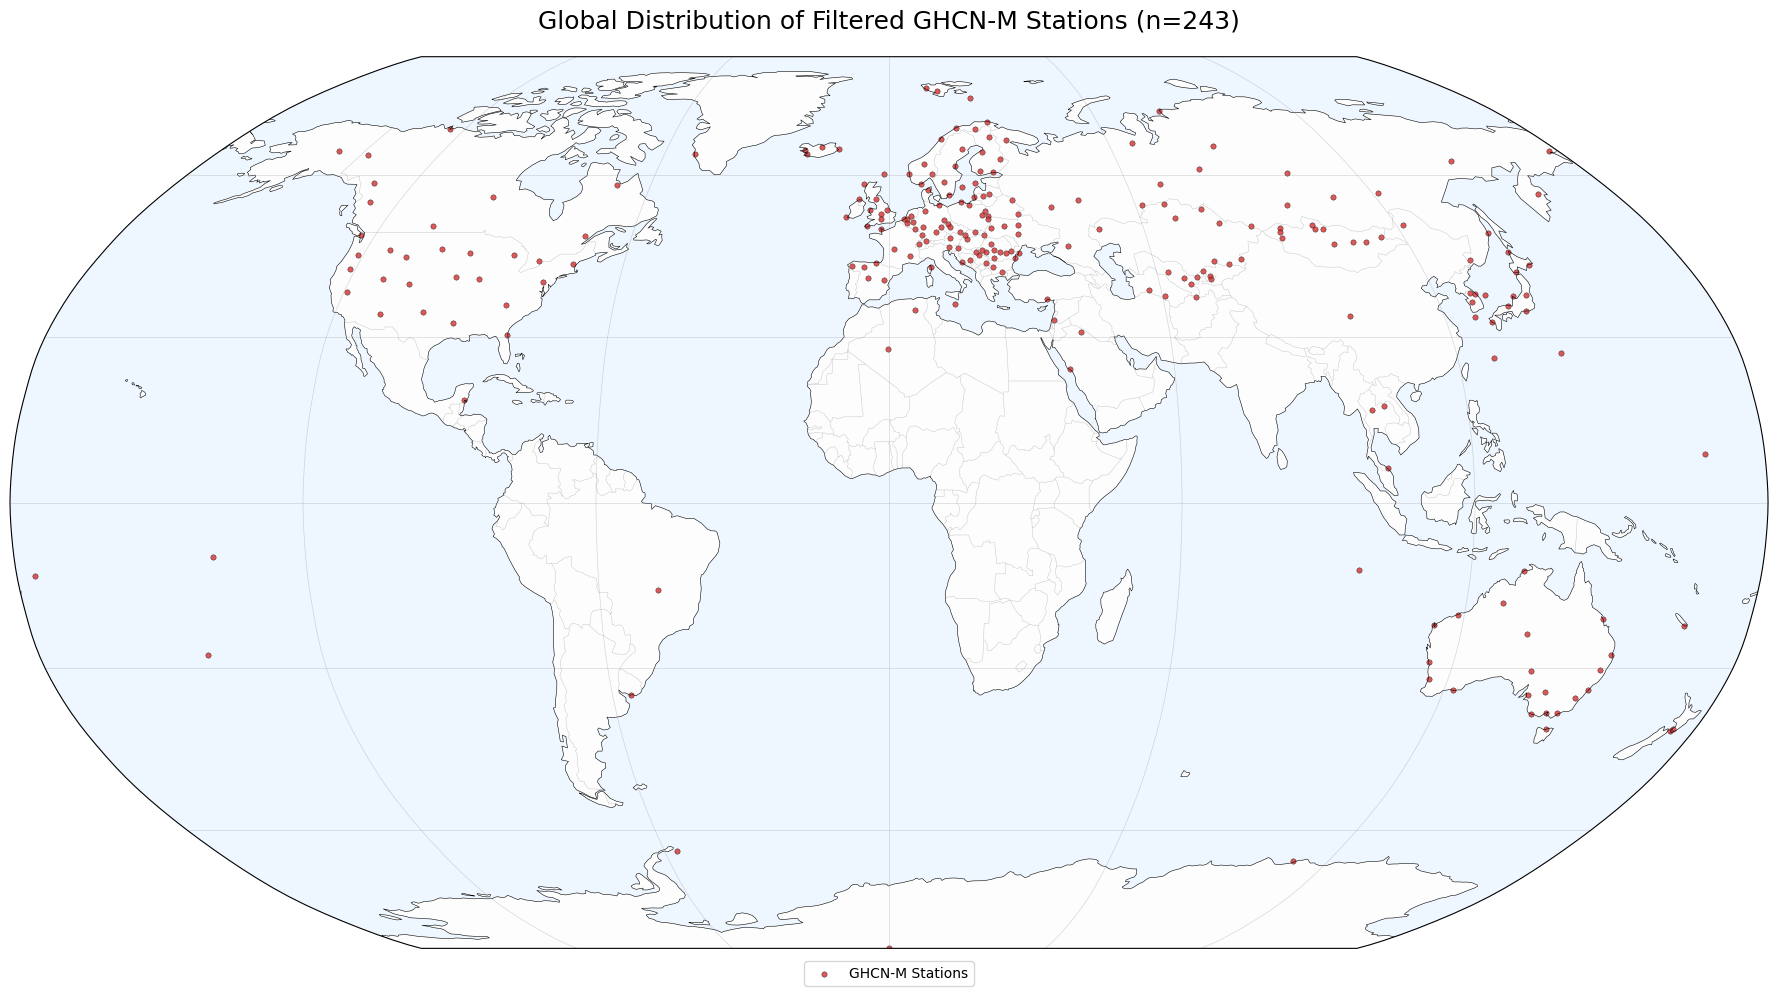

In [66]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def plot_global_stations(df):
    # 1. Setup the figure and a Global Robinson Projection
    fig = plt.figure(figsize=(20, 10))
    ax = plt.axes(projection=ccrs.Robinson())

    # 2. Add high-level geographic features for context
    ax.add_feature(cfeature.OCEAN, facecolor='#eef6ff', zorder=0)
    ax.add_feature(cfeature.LAND, facecolor='#fdfdfd', zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor='black')
    ax.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='gray', alpha=0.5)
    
    # Add a subtle grid
    ax.gridlines(draw_labels=False, dms=True, x_inline=False, y_inline=False, 
                 linewidth=0.5, color='gray', alpha=0.3)

    # 3. Plot the stations
    # We use transform=ccrs.PlateCarree() because the data is in Lat/Lon (WGS84)
    scatter = ax.scatter(
        df['LONGITUDE'], 
        df['LATITUDE'],
        transform=ccrs.PlateCarree(),
        s=15,             # Size of the dots
        color='#d32f2f',  # A strong red to stand out
        edgecolors='black',
        linewidth=0.3,
        alpha=0.8,
        label='GHCN-M Stations'
    )

    # 4. Final touches
    plt.title(f"Global Distribution of Filtered GHCN-M Stations (n={df['ID'].nunique()})", 
              fontsize=18, pad=20)
    
    # Add a legend
    plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=1, frameon=True)
    
    plt.tight_layout()
    plt.show()

# Run the plot with your final balanced dataframe
plot_global_stations(final_df)

In [69]:
##SAVE STATIONS
folder = 'data'
final_df['ID'].to_csv(os.path.join(folder,'final_stations.csv'))

# Prepare Tensors

here we are preparing a very simple MLP where the input is the size of the stations = 243.

In [11]:
## load it the stations and filter from the long df 
## reload long
df_ghcn = pd.read_parquet('/home/camarada/Documents/projects/temp-grss-nasa/ghcn_noaa/data/long_format_ghcn1990-2026.parquet')

## load stations
df_stations = pd.read_csv('/home/camarada/Documents/projects/temp-grss-nasa/ghcn_noaa/data/final_stations.csv')

df_stations.drop(columns=['Unnamed: 0'],inplace=True)

## filter for the given stations
df_ghcn = df_ghcn.loc[df_ghcn['ID'].isin(df_stations['ID'].values)]

In [23]:
df_ghcn[df_ghcn[df_ghcn.isna()].any(axis=1)]

/tmp/ipykernel_321163/473539294.py:1: FutureWarning: 'any' with datetime64 dtypes is deprecated and will raise in a future version. Use (obj != pd.Timestamp(0)).any() instead.
  df_ghcn[df_ghcn[df_ghcn.isna()].any(axis=1)]


,ID,YEAR,LATITUDE,LONGITUDE,NAME,MONTH,ELEMENT,ELEVATION,TEMPERATURE,QC_FLAG,DM,DS,Date,month_year


In [9]:
## load NASA refence
## load nasa land-ocean temp anomaly

df_nasa = pd.read_csv('/home/camarada/Documents/projects/temp-grss-nasa/data_/nasa/1981-2025.csv')

df_long = df_nasa.melt(id_vars=['Year'], var_name='Month', value_name='Value')

df_long['Date'] = pd.to_datetime(df_long['Year'].astype(str) + df_long['Month'], format='%Y%b')

# 3. Clean up: Sort by date and set it as the index
df_ts = df_long.sort_values('Date').set_index('Date').drop(columns=['Year', 'Month'])

df_ts.reset_index(inplace=True)

## create a new column YEAR-MONTH
df_ts['month_year']=pd.to_datetime(df_ts['Date']).dt.strftime("%Y-%m")

## apply scaler to celsius
df_ts['Value'] = df_ts['Value']/ 100


df_ts = df_ts.dropna(axis=0)

In [12]:
df_ts

,Date,Value,month_year
0,1981-01-01,0.53,1981-01
1,1981-02-01,0.42,1981-02
2,1981-03-01,0.48,1981-03
3,1981-04-01,0.32,1981-04
4,1981-05-01,0.24,1981-05
...,...,...,...
537,2025-10-01,1.19,2025-10
538,2025-11-01,1.21,2025-11
539,2025-12-01,1.05,2025-12
540,2026-01-01,1.08,2026-01


In [18]:

df_ghcn['Date'] = pd.to_datetime(df_ghcn['YEAR'].astype(str) + df_ghcn['MONTH'].astype(str), format='%Y%m')


# ## create a new column YEAR-MONTH
df_ghcn['month_year']=pd.to_datetime(df_ghcn['Date']).dt.strftime("%Y-%m")


In [27]:
## filter the value to be calculated
## march 
df_mar = df_ghcn.loc[df_ghcn['Date'] > datetime.datetime(2026,2,28)]

## 
df_process  = df_ghcn.loc[df_ghcn['Date'] <= datetime.datetime(2026,2,28)]

In [28]:
### Create arrays and save as npz

## root_dir =
root_dir = os.getcwd()

## sort by ID
df_process = df_process.sort_values(['Date','ID'])


uniq_id = df_process['ID'].unique()
month_years = df_process['month_year'].unique()
n_samples = len(month_years)

# Pre-allocate arrays
temp_matrices = np.zeros((n_samples, len(uniq_id)), dtype=np.float32)  ## 12*26 anos , 243 points of station
## masks = np.zeros((n_samples, n_capitals, n_timepoints), dtype=np.float32)
labels = np.zeros(n_samples, dtype=np.float32)
month_year_list = []

for idx, my in enumerate(month_years):
    print(f"processing:{my}")
    # Get data for this month/year
    month_data = df_process[df_process['month_year'] == my]

    month_data = month_data.sort_values(by=['ID'])

    temp_values = month_data['TEMPERATURE'].values

    if len(temp_values)>0:
        temp_matrices[idx, :len(temp_values)] = temp_values
        ## add mask in case necessary 
    
    # Get the true anomaly
    anomaly_value = df_ts[df_ts['month_year'] == my]['Value'].values[0]
    labels[idx] = anomaly_value
    month_year_list.append(my)



processing:1990-01
processing:1990-02
processing:1990-03
processing:1990-04
processing:1990-05
processing:1990-06
processing:1990-07
processing:1990-08
processing:1990-09
processing:1990-10
processing:1990-11
processing:1990-12
processing:1991-01
processing:1991-02
processing:1991-03
processing:1991-04
processing:1991-05
processing:1991-06


processing:1991-07
processing:1991-08
processing:1991-09
processing:1991-10
processing:1991-11
processing:1991-12
processing:1992-01
processing:1992-02
processing:1992-03
processing:1992-04
processing:1992-05
processing:1992-06
processing:1992-07
processing:1992-08
processing:1992-09
processing:1992-10
processing:1992-11
processing:1992-12
processing:1993-01
processing:1993-02
processing:1993-03
processing:1993-04
processing:1993-05
processing:1993-06
processing:1993-07
processing:1993-08
processing:1993-09
processing:1993-10
processing:1993-11
processing:1993-12
processing:1994-01
processing:1994-02
processing:1994-03
processing:1994-04
processing:1994-05
processing:1994-06
processing:1994-07
processing:1994-08
processing:1994-09
processing:1994-10
processing:1994-11
processing:1994-12
processing:1995-01
processing:1995-02
processing:1995-03
processing:1995-04
processing:1995-05
processing:1995-06
processing:1995-07
processing:1995-08
processing:1995-09
processing:1995-10
processing:1

In [29]:
temp_matrices.shape

(434, 243)

In [30]:
# Save to npz file
path_output = '/home/camarada/Documents/projects/temp-grss-nasa/data_/tensors_ready/NASA-TEMP-LAND-OCEAR'
os.makedirs(path_output, exist_ok = True) 
np.savez_compressed(
    os.path.join(path_output, 'noaa-2000-2026fev-temp-clean.npz'),
    temp_matrices=temp_matrices,  # shape: (n_samples, n_capitals, n_timepoints)
    labels=labels,                # shape: (n_samples,)
    month_years=np.array(month_year_list, dtype='U'),  # shape: (n_samples,)
    capitals=np.array(uniq_id, dtype='U')         # shape: (n_capitals,)
)

In [ ]:
np.save_compressed(
    os.path.join(path_output, 'noaa-2026mar-temp.npz'),
    temp_matrices=temp_matrices,  # shape: (n_samples, n_capitals, n_timepoints)
)

In [31]:
df_mar['TEMPERATURE'].values

array([nan, nan, nan, ..., nan, nan, nan], shape=(2430,))

In [32]:
df_mar

,ID,YEAR,LATITUDE,LONGITUDE,NAME,MONTH,ELEMENT,ELEVATION,TEMPERATURE,QC_FLAG,DM,DS,Date,month_year
7466,AGE00147718,2026,34.8500,5.7200,BISKRA,3,TAVG,125.0,NaN,None,NaN,None,2026-03-01,2026-03
31490,AGM00060620,2026,27.8380,-0.1860,TOUAT_CHEIKH_SIDI_MOHAMED_BEL,3,TAVG,280.1,NaN,None,NaN,None,2026-03-01,2026-03
91706,ASN00002012,2026,-18.2292,127.6636,HALLS_CREEK_AIRPORT,3,TAVG,422.0,NaN,None,NaN,None,2026-03-01,2026-03
97490,ASN00004032,2026,-20.3725,118.6317,PORT_HEDLAND_AIRPORT,3,TAVG,6.4,NaN,None,NaN,None,2026-03-01,2026-03
99398,ASN00005007,2026,-22.2406,114.0967,LEARMONTH_AIRPORT,3,TAVG,5.0,NaN,None,NaN,None,2026-03-01,2026-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6679739,UZM00038611,2026,40.9830,71.5830,NAMANGAN,12,TAVG,474.0,NaN,None,NaN,None,2026-12-01,2026-12
6680387,UZM00038618,2026,40.3667,71.7500,FERGANA,12,TAVG,577.0,NaN,None,NaN,None,2026-12-01,2026-12
6681527,UZM00038696,2026,39.5667,66.9500,SAMARKAND,12,TAVG,724.0,NaN,None,NaN,None,2026-12-01,2026-12
6684551,UZM00038927,2026,37.2294,67.2694,TERMEZ,12,TAVG,309.0,NaN,None,NaN,None,2026-12-01,2026-12


In [36]:
df_ghcn.loc[(df_ghcn['Date']>=datetime.datetime(2026,3,1))&(df_ghcn['Date']<=datetime.datetime(2026,3,31))]

,ID,YEAR,LATITUDE,LONGITUDE,NAME,MONTH,ELEMENT,ELEVATION,TEMPERATURE,QC_FLAG,DM,DS,Date,month_year
7466,AGE00147718,2026,34.8500,5.7200,BISKRA,3,TAVG,125.0,NaN,None,NaN,None,2026-03-01,2026-03
31490,AGM00060620,2026,27.8380,-0.1860,TOUAT_CHEIKH_SIDI_MOHAMED_BEL,3,TAVG,280.1,NaN,None,NaN,None,2026-03-01,2026-03
91706,ASN00002012,2026,-18.2292,127.6636,HALLS_CREEK_AIRPORT,3,TAVG,422.0,NaN,None,NaN,None,2026-03-01,2026-03
97490,ASN00004032,2026,-20.3725,118.6317,PORT_HEDLAND_AIRPORT,3,TAVG,6.4,NaN,None,NaN,None,2026-03-01,2026-03
99398,ASN00005007,2026,-22.2406,114.0967,LEARMONTH_AIRPORT,3,TAVG,5.0,NaN,None,NaN,None,2026-03-01,2026-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6679730,UZM00038611,2026,40.9830,71.5830,NAMANGAN,3,TAVG,474.0,NaN,None,NaN,None,2026-03-01,2026-03
6680378,UZM00038618,2026,40.3667,71.7500,FERGANA,3,TAVG,577.0,NaN,None,NaN,None,2026-03-01,2026-03
6681518,UZM00038696,2026,39.5667,66.9500,SAMARKAND,3,TAVG,724.0,NaN,None,NaN,None,2026-03-01,2026-03
6684542,UZM00038927,2026,37.2294,67.2694,TERMEZ,3,TAVG,309.0,NaN,None,NaN,None,2026-03-01,2026-03
